# 00 — Metodología

Genera las tres figuras metodológicas del TFG:

1. **Arquitectura MonitorSystem** — diseño de los dos hilos de monitorización
2. **Diagrama FoM** — composición de la Figura de Mérito (FoM_full y FoM_red)
3. **Matriz experimental E0–E5** — configuración de los seis experimentos

Las figuras se guardan en `notebooks/figures/` en PDF y SVG para su inclusión en la memoria del TFG.

In [1]:
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here.parent.parent if _here.name == "secundarios" else _here.parent
sys.path.insert(0, str(_root / "src"))

from monitorviz.viz import setup_style, plot_monitor_architecture, plot_fom_diagram, plot_experiment_matrix

setup_style()

FIG_DIR = _here.parent / "figures" if _here.name == "secundarios" else pathlib.Path("figures")
FIG_DIR.mkdir(exist_ok=True)
print(f"Figuras → {FIG_DIR.resolve()}")

Figuras → /home/yisus/PycharmProjects/Visualizer/notebooks/figures


## Figura 1 — Arquitectura MonitorSystem

Diagrama de bloques del binario C++ que produce los datos de este TFG.
Muestra los dos hilos paralelos (inferencia y hardware) y los artefactos
generados por cada ejecución.

Figura 1 guardada.


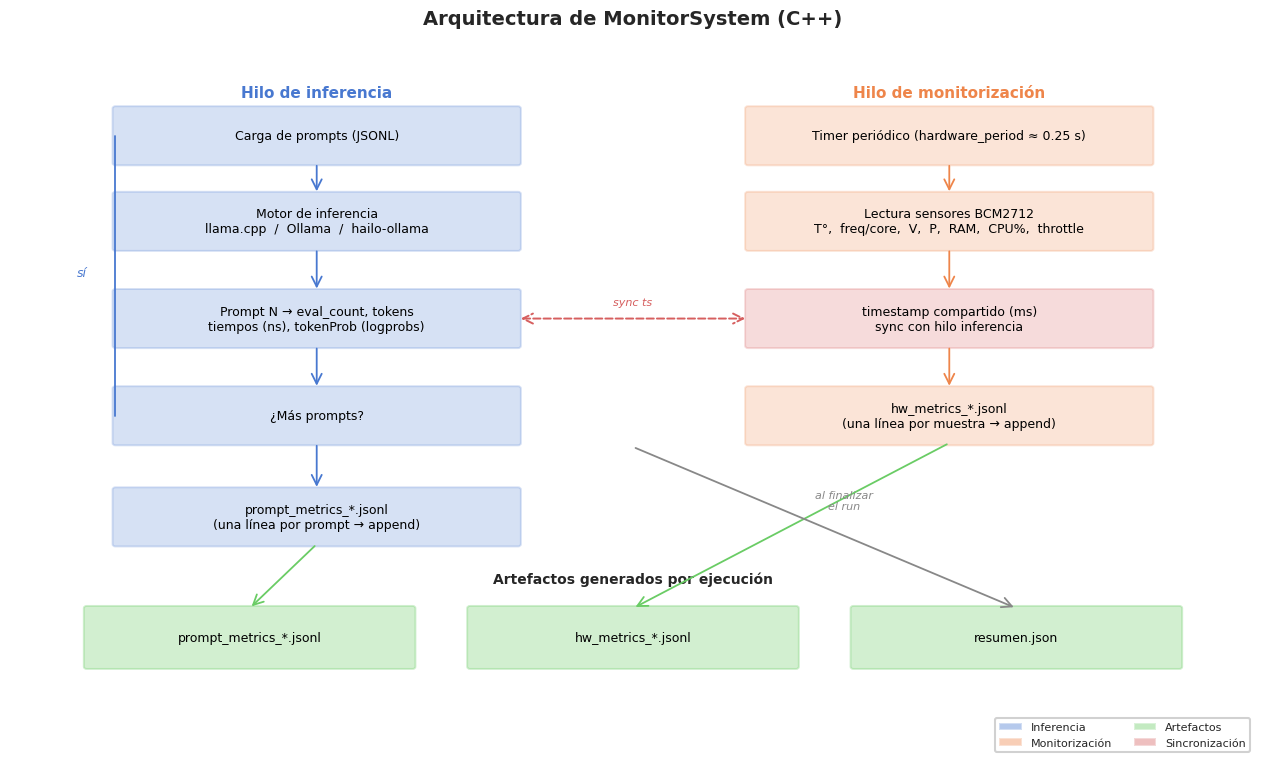

In [2]:
plot_monitor_architecture(save_path=FIG_DIR / "fig_monitor_architecture", fmt=("pdf", "svg"))
print("Figura 1 guardada.")

## Figura 2 — Diagrama FoM

Representación conceptual de la Figura de Mérito compuesta:

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

y la versión reducida para E5 (intra-modelo, normalizada respecto al baseline CPU):

$$\text{FoM\_red} = \sqrt{T_{5,norm} \cdot \varepsilon_{5,norm}}$$

**Referencia de normalización**: llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512 · seed=42 · T=0.0

Figura 2 guardada.


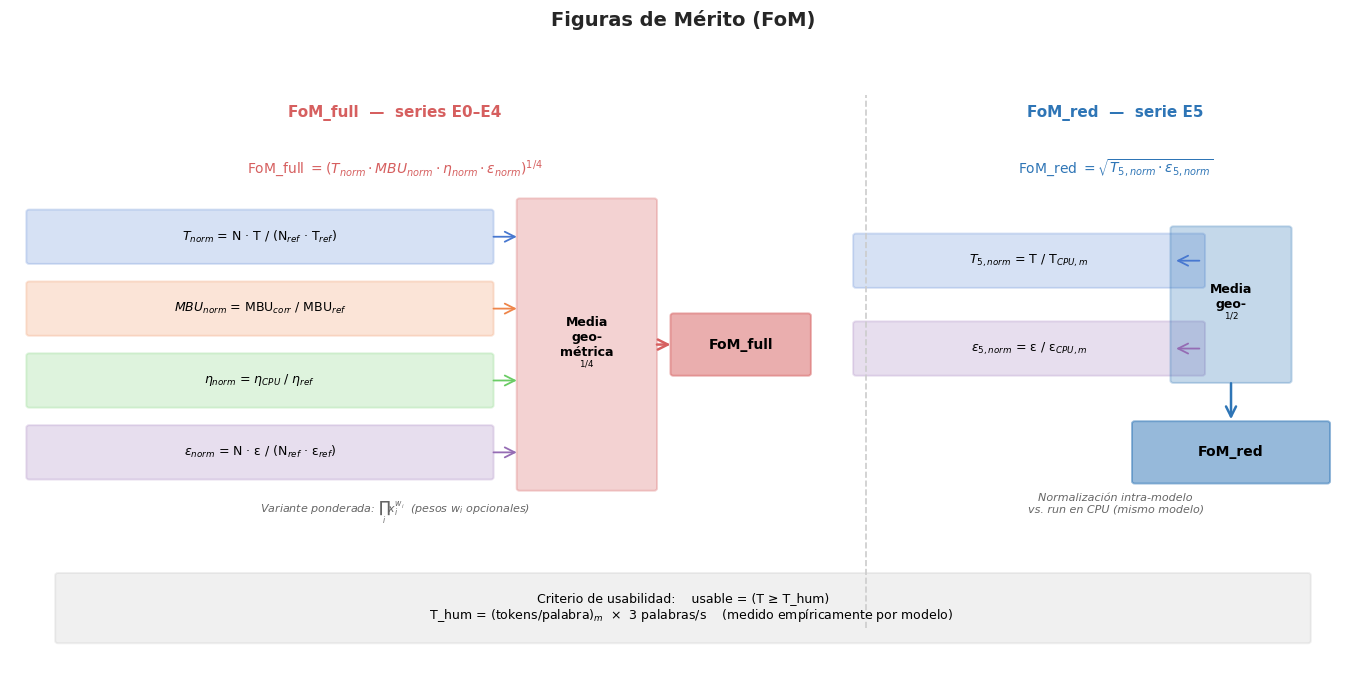

In [3]:
plot_fom_diagram(save_path=FIG_DIR / "fig_fom_diagram", fmt=("pdf", "svg"))
print("Figura 2 guardada.")

## Figura 3 — Matriz Experimental E0–E5

Tabla resumen de los seis experimentos del TFG con sus variables independientes
y el conjunto de modelos/configuraciones evaluados.

Edita `EXPERIMENT_DATA` si los placeholders no coinciden con los experimentos finales.

Figura 3 guardada.


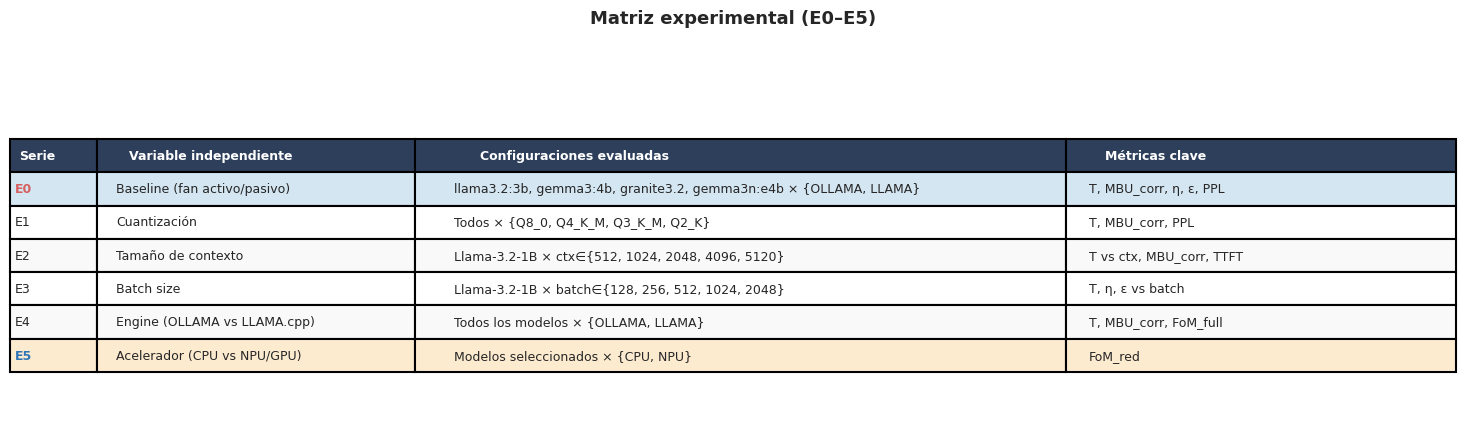

In [4]:
EXPERIMENT_DATA = [
    ["E0", "Baseline (fan activo/pasivo)",
     "llama3.2:3b, gemma3:4b, granite3.2, gemma3n:e4b × {OLLAMA, LLAMA}",
     "T, MBU_corr, η, ε, PPL"],
    ["E1", "Cuantización",
     "Todos × {Q8_0, Q4_K_M, Q3_K_M, Q2_K}",
     "T, MBU_corr, PPL"],
    ["E2", "Tamaño de contexto",
     "Llama-3.2-1B × ctx∈{512, 1024, 2048, 4096, 5120}",
     "T vs ctx, MBU_corr, TTFT"],
    ["E3", "Batch size",
     "Llama-3.2-1B × batch∈{128, 256, 512, 1024, 2048}",
     "T, η, ε vs batch"],
    ["E4", "Engine (OLLAMA vs LLAMA.cpp)",
     "Todos los modelos × {OLLAMA, LLAMA}",
     "T, MBU_corr, FoM_full"],
    ["E5", "Acelerador (CPU vs NPU/GPU)",
     "Modelos seleccionados × {CPU, NPU}",
     "FoM_red"],
]

plot_experiment_matrix(
    data=EXPERIMENT_DATA,
    save_path=FIG_DIR / "fig_experiment_matrix",
    fmt=("pdf", "svg"),
)
print("Figura 3 guardada.")